# Module 2: Epidemic Modeling Using SEIR

## Team Members:
Isabella Orlando and Hayden Rue

## Project Title:
Epidemic Trajectory Prediction and Intervention Analysis of a Mystery Virus Using SEIR Modeling
## Project Goal:
This project seeks to answer the question: How can the SEIR model be used to predict the peak day and number of active cases of a mystery virus when given early stage data, find the error of the prediction after the full data release, and determine the best intervention methods to implement for other outbreaks of the same or similar viruses?

## Statement of AI Usage: 
Throughout this project, Chat GPT was used to assist the exponential fitting, grid search, and implementation of Eulers method. Claude was also used to debug intervention strategies and create an organized plot and table of the output of all intervention strategies.

## 1. Data and disease background

* Prevalence and Incidence: Prevalence of the disease refers to the number of existing cases in the total population, which in this case is 17,900 undergraduate students at the University of Virginia. Prevalence data from the releases after days 45, 70 and 120, which translates directly to the I(t) value in the SEIR model. Incidence refers to the number of new cases over a specific period, which increased rapidly at first according to the dataset. Incidence must be inferred from these changes in active cases, which can introduce uncertainty from any information delays or discrepancies.
* Economic Burden: Respiratory virus outbreaks can create a significant economic burden for universities and surrounding communities. Healthcare, testing resources, and self-isolation or quarantine locations are examples of costs that must be provided to maintain public safety. Operational costs or slowed productivity may result from closures, masking policies, or missed classes resulting overall in a decrease in university function. These economic impacts are closely related to model predictions because a higher peak in cases increases the economic burden.
* Symptoms: Similar to other respiratory viral infections, symptoms include a rash and low fever, along with fatigue and a sore throat. Gastrointestinal symptoms and joint pain were also reported among individuals. The incubation period is approximately 9-12 days which relates directly to the sigma value in the SEIR model, representing the rate at which exposed individuals become infectious.
* Biological mechanisms: The virus that is the cause for the disease outbreak is spread through respiratory droplets, affecting the transmission rate (beta) in the SEIR model. When viral particles enter the respiratory tract, the virus can reach the cell lining. A viral particle then enters and infects the host cell, replicates its genetic material, and is released to affect another cell in the body. An immune response, noticeable from inflammation and a fever, is stimulate to combat the virus. The genome of the virus was identified as RNA, meaning that viral replication occurs using an RNA-based mechanism that is similar to many respiratory viruses.
https://pmc.ncbi.nlm.nih.gov/articles/PMC7150055/

## 2. Data Analysis

At each stage of data release, predictions remained provisional and were updated as new information became available. The exponential fit from release #1 provided an initial estimate of outbreak trends, specifically for the initial exponential growth phase. Confidence in the model increased with release #2 through full SEIR optimization, and the final validation against release #3 allowed for error calculations and intervention modeling.

### 2a. Methods


This project used a combination of exponential growth and SEIR  modeling to analyze and predict the trajectory of a mystery virus outbreak in a population of 17,900 people. Exponential growth modeling is appropriate during the initial phase, because the susceptible remains nearly constant. As the susceptible population decreases, the model requires a transition to an SEIR model. Early stage data (through day 45) was fit to an exponential curve to estimate the initial growth rate, which was then used to approximate R0. The SEIR model was then solved numerically using Euler's method with a daily time step, dividing the population into Susceptible, Exposed, Infectious, and Recovered compartments. Parameter ranges for β, γ, and σ were selected based on biological characteristics of respiratory values, such as expected incubation and recovery time ranges. Model parameters (β, γ, σ) were then optimized by minimizing the sum of squared error (SSE) between the model output and observed active case counts via grid search. The fitted model was projected forward to predict the peak day and total active cases of the outbreak, and it was later validated against the full dataset released in data release #3.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
Using the data gained from data release #1, the number of active cases through day 45 were plotted.

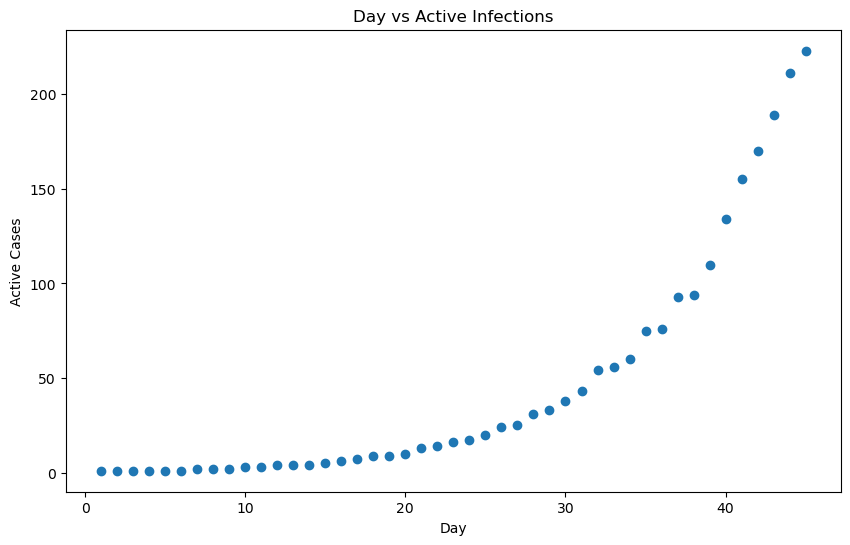

In [ ]:
#%%
import pandas as pd
import matplotlib.pyplot as plt

#%%
# Read the data
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv", parse_dates=['date'], header=0, index_col=None)

#%%
# Create and label a plot of the active cases over time
plt.figure(figsize=(10, 6))
plt.scatter(df['day'], df['active reported daily cases'])
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Day vs Active Infections')
plt.show()

Trends and key points from the data:
* The initial number of infections is small but begins to increase rapidly around day 25, marking a transition into an exponential growth phase.
* The curve of the graph suggests exponential growth because as the number of infected individuals increases so does the total number of new infections in a nonlinear fashion, supporting the use of an exponential model to estimate early growth rate.
* The growth rate and doubling time provide measures of how quickly the virus is spreading, which can be used to approximate R0 for the early outbreak phase.
* Knowing how contagious the virus is, population size, presence of immunity, and the length of infectious period, both symptomatic and asymptomatic, will be helpful in predicting an accurate curve for the outbreak.

Estimated r: 0.131365895627797
Estimated I0: 0.7111198627565817
Estimated R0: 1.9286677472085472


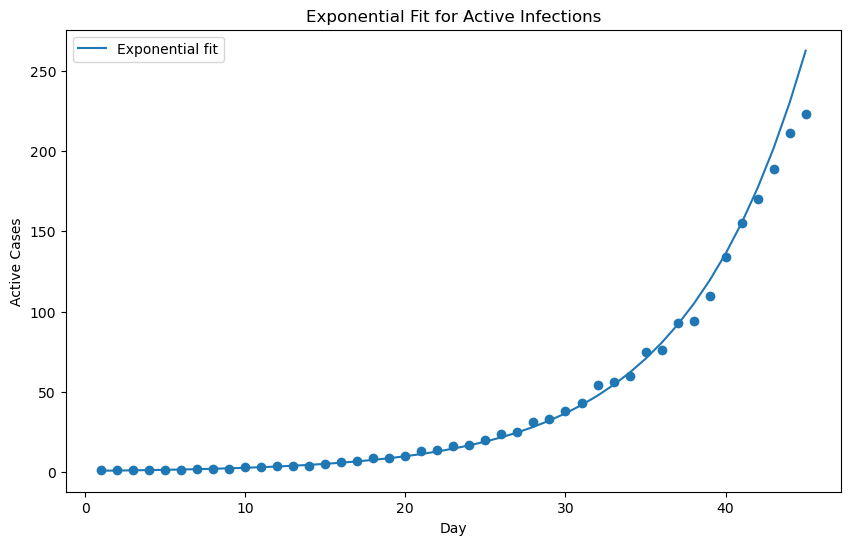

In [ ]:
#%%
import pandas as pd
import matplotlib.pyplot as plt

#%%
# Read the data
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv", parse_dates=['date'], header=0, index_col=None)

import numpy as np

#Get values from variables in csv
t = df["day"].values
I = df["active reported daily cases"].values

#only examine first 45 days for early exponential growth
mask = t <= 45
t_exp = t[mask]
I_exp = I[mask]

#%%
#linearize to use polyfit and get r from slope

# Remove zeros before log
positive_mask = I_exp > 0
t_fit = t_exp[positive_mask]
I_fit = I_exp[positive_mask]

log_I = np.log(I_fit)

# Linear regression
coeffs = np.polyfit(t_fit, log_I, 1)
r = coeffs[0]
log_I0 = coeffs[1]
I0 = np.exp(log_I0)

# print growth rate and estimated initial infections
print("Estimated r:", r)
print("Estimated I0:", I0)

#%%
#Estimate R0

D = 5
R0 = np.exp(r * D)

print("Estimated R0:", R0)


#%%
# Create and label a plot of the active cases over time with exponential fit for growth rate

I_model = I0 * np.exp(r * t)

#Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['day'], df['active reported daily cases'])
plt.plot(t, I_model, label = "Exponential fit")
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Exponential Fit for Active Infections')
plt.legend()
plt.show()

Due to the exponential nature of the data, an exponential fit was used to estimate the early growth rate, which was then used to approximate R0. The data was linearized using a logarithmic function, allowing the growth rate to be estimated using linear regression. The Estimated R0 value was 1.9286677472085472, signifing that approximately 2 people will become infected for every person infected through this early stage of the outbreak. The R0 estimate value is provisional because it is based on early outbreak data, not taking into account incubation or recovery characteristics.


To help predict the trend of the data beyond day 45, we can compare the R0 from the mystery virus to other moderately contagious viral diseases. Ebola and EV-D68 are viruses that have similar R0s around 2.

Ebola is an often fatal virus that results in hemorrhagic illness. It is believed to come from fruit bats with periodic outbreaks present in Central and West Africa. While it has a similar R0 value, its mechanism of transmission is different from the mechanism present in this outbreak.

EV-D68 is a virus that causes respiratory illness, ranging from mild to severe depending on the susceptibility of the person infected. The virus was originally rare, however outbreaks have increased and are showing symptoms related to neurological conditions and muscle weakness. This virus aligns more closely with both the R0 value and transmission mechanism.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
The SEIR model was solved using Euler's method with a step size of h=1 day to align with daily case reporting in the data. The model divides the sample population (17,900) into Susceptible, Exposed, Infectious, and Recovered with the initial conditions of one infected.

For each step, the following differential equations were approximated to measure the progression of individuals through disease states over time:

* dS/dt = -(β x S x I) / N
* dE/dt = (β x S x I) / N - σE
* dI/dt = σE - γI
* dR/dt = γI

β represents transmission rate, σ is 1/incubation period, and γ is the recovery rate. Each compartment of the model was updated by adding the product of the derivative and the step size for each day.

In [ ]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)


### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
To fit the SEIR model to the data from release #2, a grid search optimization of the parameters β, σ, and γ was performed. To inform the parameter ranges used for the search, the R0 estimate was used from the early exponential data since R0 = β/γ.

Search ranges:

* β: 0.1 to 0.5 (10 values)
* γ: 0.05 to 0.2 (10 values)
* σ: 0.1 to 0.5 (10 values)

For each set of parameters, Euler's method was run and the resulting output was compared to active cases using the sum of squared error(SSE). The combinations that minimized SSE were determined to be optimal.

Optimal values:

* β = 0.5
* γ = 0.2
* σ ≈ 0.322
* SSE ≈ 139514

The optimized parameters suggest a relatively high transmission rate (β = 0.5) and moderate recovery rate (γ = 0.2), which corresponds to an infectious period of about 5 days. The σ value indicates an incubation period of about 3 days.

This gives a new fitted R0 of 2.5, which is relatively consistent with the early-stage estimate of 1.93. The discrepancy is caused by the inclusion of σ in the SEIR model, whereas the initial estimate used e^(r*D), where D was assumed to be 5 days. If the true infectious period differs from 5, the initial R0 estimate will be directly effected. Also, the esponential fit only used data through day 45, whereas the SEIR model was able to take data through day 70, improving its accuracy.

With a new value for R0, the mystery virus is likely to be Enterovirus D68 (EV-D68). An R0 ~2.5 fits Enterovirus, and the respiratory transmission via droplets and target of younger population matches the known data. Additionally, the symptom profile of rash, fatigue, and sore throat, along with the RNA genome and incubation period of 9-12 days are consistent with EV-D68. Ebola was ruled out due to its distinct transmission mechanism and unique hemorrhagic symptoms.


In [ ]:
# Optimzation (grid search)
# Use estimated R0 to make an estimate for beta and gamma. R0 = 1.93 so beta = 1.93 * gamma
beta_values = np.linspace(0.1,0.5,10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

#Grid search to obtain optimal parameters
optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

#Find lowest sse by running eulers method for each parameter
for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            _, _, I_model, _ = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) **2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma


#Run model using new optimal parameters
I_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

### 2e. Plot the model-predicted infections over time compared to the data.
The optimal parameters from the grid search were used to plot the SEIR predictions of active cases through day 70 from the data of release #2. The model curve closely matches the data during the early exponential growth phase, but begins to deviate as the days increase beyond 45. The new fit confirms the optimal parameters produce a reasonable approximation of the outbreak trend up to this point.

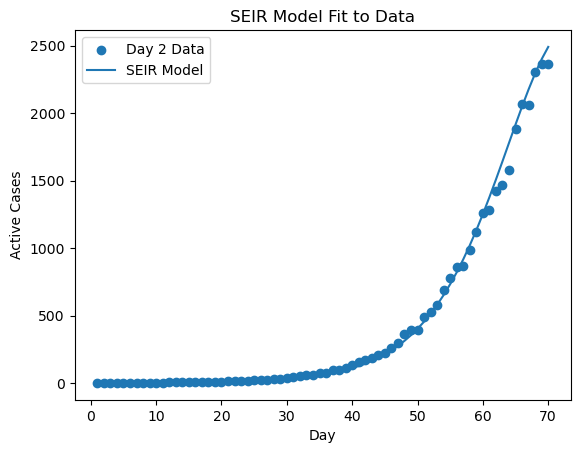

In [ ]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)

# Optimzation (grid search)
# Use estimated R0 to make an estimate for beta and gamma. R0 = 1.93 so beta = 1.93 * gamma
beta_values = np.linspace(0.1,0.5,10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

#Grid search to obtain optimal parameters
optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

#Find lowest sse by running eulers method for each parameter
for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            I_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) **2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma


#Run model using new optimal parameters
I_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

#Plot the model vs given data
plt.figure()
plt.scatter(day, active, label ="Day 2 Data")
plt.plot(day, I_best[:len(day)], label ="SEIR Model")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("SEIR Model Fit to Data")
plt.legend()
plt.show()



### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
Using the optimal SEIR parameters, the model was projected forward to 200 days to predict the full trajectory of the outbreak. The peak number of active infections was identified by finding the maximum of the predicted I(t) curve. The model predicted a peak of approximately 2,652 active cases occurring on day 73.

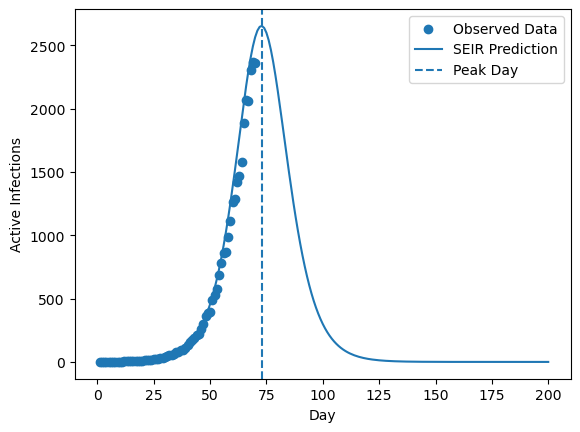

In [ ]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)

# Optimzation (grid search)
# Use estimated R0 to make an estimate for beta and gamma. R0 = 1.93 so beta = 1.93 * gamma
beta_values = np.linspace(0.1,0.5,10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

#Grid search to obtain optimal parameters
optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

#Find lowest sse by running eulers method for each parameter
for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            I_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) **2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma


#Run model using new optimal parameters
I_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

#Predict future trends
future_days = 200

#Run eulers method on future days and find peak infections and peak day
I_future = run_euler(optimal_beta, optimal_sigma, optimal_gamma, future_days)
peak_infections = np.max(I_future)
peak_day = np.argmax(I_future)

plt.figure()
plt.scatter(day, active, label="Observed Data")
plt.plot(range(len(I_future)), I_future, label="SEIR Prediction")
plt.axvline(peak_day, linestyle="--", label="Peak Day")
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.legend()
plt.show()

The peak number of active infections (2,652) occuring at day 73 is a resonable prediction considering the large population size of 17,900. This means about 15% of the population is infected on the peak, or 73rd day.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
From the release of the full dataset (Data release #3), the SEIR model predictions were compared vs the true active cases through day 121. The optimal parameters from the grid search were applied to the full 121 days. The model predicted a peak on day 73 with 2,652 active cases, while the true data showed a peak on  day 82 with ~3,200 active cases, yielding a relative error of ~12% for peak day and ~19.5% for peak active cases. The discrepancy is likely attributable to the limited parameter combinations tested of the grid search as well as the inherent limitations of Euler's method accumulating numerical error over long time intervals.

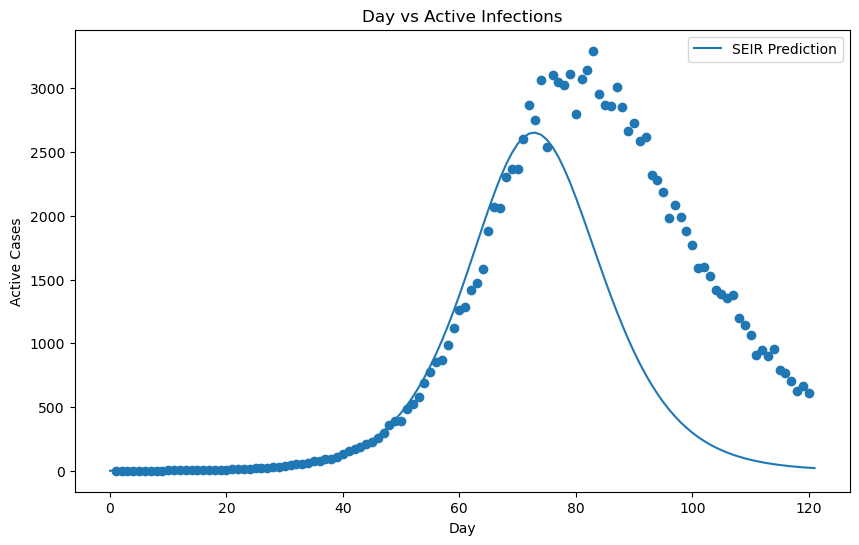

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

days = 121
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Load data from csv file
#df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv")
day = df["day"].values
active = df["active reported daily cases"].values

def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)


optimal_beta = .5
optimal_gamma = .2
optimal_sigma = .32222222222

I_future = run_euler(optimal_beta, optimal_sigma, optimal_gamma, days)

plt.figure(figsize=(10, 6))
plt.scatter(df['day'], df['active reported daily cases'])
plt.plot(range(len(I_future)), I_future, label="SEIR Prediction")
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Day vs Active Infections')
plt.legend()
plt.show()

### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
Five interventions were analyzed to predict their effects on the peak number of active cases and the day the peak occurred, all implemented starting at day 70 when the epidemic begins to gain significant traction in the VT population.

The first intervention was a staged vaccine rollout, where 1000 students were vaccinated with 90% efficacy on each of the days 70, 80, and 90. The second was a single mass vaccination event on day 70, where 2000 students were vaccinated at 90% efficacy . In both cases, effectively vaccinated individuals were directly moved from the susceptible to the recovered populations. The timing of vaccination has a notable effect on outcomes. If vaccines been available earlier than day 70, the susceptible pool would be smaller at the point of rapid growth, likely resulting in a more significant reduction of peak cases. Similarly, the staged rollout distributes immunity over time, which may be more logistically feasible but provides less immediate protection compared to the single vaccine event.

The third intervention modeled a testing and quarantine mandate starting at day 70, which reduced the infectious period by 2 days by increasing gamma. This simulates a scenario where infected individuals, including asymptomatic cases, are identified quickly and isolated from the susceptible population. However, this model assumes 100% compliance. At 50% compliance, the effective reduction in infectious period would be approximately halved, producing a far less productive effect on the curve. Earlier implementation of testing would allow more cases to be caught during the exponential growth phase, improving its effectiveness.

The fourth intervention features a complete school closure for 2 weeks. During this period, contacts drop to 20% starting on day 70. A notable observation from the model is that this intervention produces a two-peak curve, where a suppressed first peak during closure is followed by a rebound when contacts return to normal. This rebound occurs because closure delays transmission rather than eliminating or reducing it, and a large susceptible pool remains when restrictions are lifted. This result highlights an important ethical dilemma: school closure disproportionately burdens lower-income students who rely on campus resources, dining, and housing, while providing only temporary suppression without a long-term strategy such as vaccination.


The fifth intervention was a masking mandate from day 70, reducing beta by 40%. The percent reduction in peak cases scales nonlinearly with masking effectiveness. A 20% reduction in beta produces a disproportionately smaller effect than a 40% reduction because transmission compounds exponentially. If masking had been implemented earlier, the curve would have been flatter from the start, potentially preventing the epidemic from reaching its peak altogether.

Overall, the best strategy for VT to adopt around day 70 of their epidemic would be testing and quarantining. However, if the school is unable to ensure a large percentage of compliance, a mask mandate would be the next best option. Masking at day 70, peak cases only reached 2250, 2 days after the mandate. This is almost a 60% reduction in peak number of cases and avoids harming less-fortunate groups through a school closure.



Optimal Beta: 0.4111111111111111
Optimal Sigma: 0.5
Optimal Gamma: 0.2
Optimal SSE: 15610107.112685319

Scenario                    Peak Cases   Peak Day
--------------------------------------------------
No Intervention                   3722         84
Vaccine (single)                  3255         83
Vaccine (rollout)                 3446         82
Testing + Quarantine              2043         70
School Closure                    2210         71
Masking Mandate                   2250         72


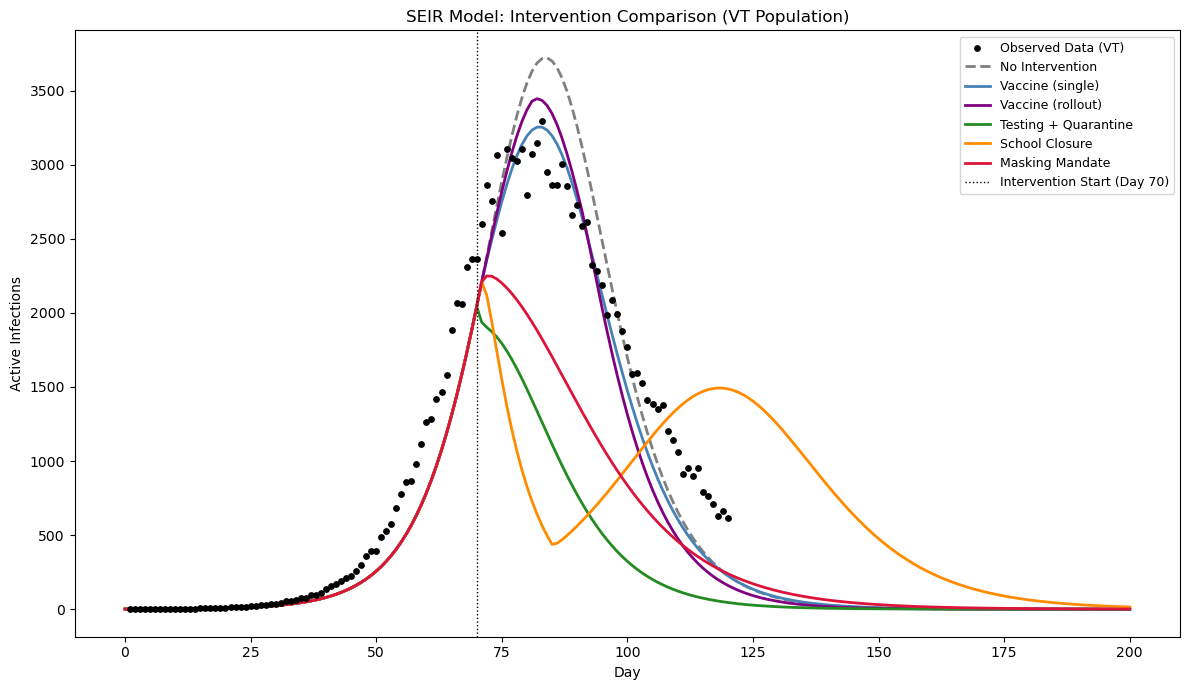

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv")
day    = df["day"].values
active = df["active reported daily cases"].values

# Population & initial conditions for VT
N  = 31000
S0, E0, I0, R0_init = N - 1, 0, 1, 0

# Solve SEIR 
def run_euler(beta, sigma, gamma, total_days,
              beta_modifier=1.0,
              gamma_modifier=1.0,
              intervention_day=None,
              move_to_R=None,
              school_closure=None):
    
    S, E, I, R = [S0], [E0], [I0], [R0_init]
    h = 1  # daily time step

    if move_to_R is None:
        move_to_R = []

    for t in range(total_days):

        # Vaccination: move vaccinated individuals from S to R 
        for vax_day, vax_count in move_to_R:
            if t == vax_day:
                actual = min(S[t], vax_count)  # can't vaccinate more than susceptibles
                S[t] -= actual
                R[t] += actual

        # Determine effective beta for this time step
        current_beta = beta  # default

        if school_closure is not None:
            close_start, close_end = school_closure
            if close_start <= t < close_end:
                current_beta = beta * 0.20        # 20% of normal contacts during closure
            elif t >= close_end:
                current_beta = beta               # return to normal after closure
        elif intervention_day is not None and t >= intervention_day:
            current_beta = beta * beta_modifier   # masking

        # Determine effective gamma for this time step
        current_gamma = gamma  # default

        if intervention_day is not None and t >= intervention_day:
            current_gamma = gamma * gamma_modifier  # quarantine speeds up recovery

        # SEIR derivatives
        dS = -(current_beta * S[t] * I[t]) / N
        dE =  (current_beta * S[t] * I[t]) / N - (sigma * E[t])
        dI =  (sigma * E[t]) - (current_gamma * I[t])
        dR =  (current_gamma * I[t])

        # Updating Euler
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)

    return np.array(S), np.array(E), np.array(I), np.array(R)


# Grid search fitted to VT population (N=31000)
beta_values  = np.linspace(0.1, 0.5, 10)
gamma_values = np.linspace(0.05, 0.2, 10)
sigma_values = np.linspace(0.1, 0.5, 10)

optimal_sse   = np.inf
optimal_beta  = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            _, _, I_model, _ = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) ** 2)

            if sse < optimal_sse:
                optimal_sse   = sse
                optimal_beta  = beta
                optimal_gamma = gamma
                optimal_sigma = sigma

print("Optimal Beta:",  optimal_beta)
print("Optimal Sigma:", optimal_sigma)
print("Optimal Gamma:", optimal_gamma)
print("Optimal SSE:",   optimal_sse)

# Future projection 
future_days = 200

# No interventions
_, _, I_baseline, _ = run_euler(optimal_beta, optimal_sigma, optimal_gamma, future_days)

# Intervention 1a: Single vaccine event on day 70
# 2000 students vaccinated with 90% efficacy
efficacy   = 0.90
vax_single = [(70, int(2000 * efficacy))]  # 1800 moved from S to R on day 70

_, _, I_vax_single, _ = run_euler(
    optimal_beta, optimal_sigma, optimal_gamma, future_days,
    move_to_R=vax_single
)

# Intervention 1b: Vaccine rollout (day 70, 80, 90)
# 1000 students per event × 90% efficacy
vax_rollout = [
    (70, int(1000 * efficacy)),   # 900 on day 70, 80, 90
    (80, int(1000 * efficacy)), 
    (90, int(1000 * efficacy)), 
]

_, _, I_vax_rollout, _ = run_euler(
    optimal_beta, optimal_sigma, optimal_gamma, future_days,
    move_to_R=vax_rollout
)

# Intervention 2: Testing + quarantine from day 70 
# Reduces infectious period by 2 days, therefore gamma increases
# New gamma = 1 / (1/gamma - 2)
original_infectious_period = 1 / optimal_gamma
new_infectious_period      = original_infectious_period - 2
quarantine_gamma           = 1 / new_infectious_period
gamma_modifier             = quarantine_gamma / optimal_gamma

_, _, I_quarantine, _ = run_euler(
    optimal_beta, optimal_sigma, optimal_gamma, future_days,
    gamma_modifier=gamma_modifier,
    intervention_day=70   # quarantine at day 70
)

# Intervention 3: School closure for 2 weeks starting day 70
# Contacts drop to 20% during closure then return to normal
_, _, I_closure, _ = run_euler(
    optimal_beta, optimal_sigma, optimal_gamma, future_days,
    school_closure=(70, 84)   # 14-day closure window
)

# Intervention 4: Masking mandate from day 70
# Reduces transmission by 40% so beta × 0.60 after day 70 
_, _, I_masking, _ = run_euler(
    optimal_beta, optimal_sigma, optimal_gamma, future_days,
    beta_modifier=0.60,
    intervention_day=70   # masking at day 70
)

# Print peak stats for all interventions 
scenarios = {
    "No Intervention":      I_baseline,
    "Vaccine (single)":     I_vax_single,
    "Vaccine (rollout)":    I_vax_rollout,
    "Testing + Quarantine": I_quarantine,
    "School Closure":       I_closure,
    "Masking Mandate":      I_masking,
}

print(f"\n{'Scenario':<25} {'Peak Cases':>12} {'Peak Day':>10}")
print("-" * 50)
for name, I_arr in scenarios.items():
    print(f"{name:<25} {np.max(I_arr):>12.0f} {np.argmax(I_arr):>10}")

# Plot all interventions 
plt.figure(figsize=(12, 7))
plt.scatter(day, active, color="black", s=15, label="Observed Data (VT)", zorder=5)

colors     = ["gray", "steelblue", "purple", "forestgreen", "darkorange", "crimson"]
linestyles = ["--", "-", "-", "-", "-", "-"]

for (name, I_arr), color, ls in zip(scenarios.items(), colors, linestyles):
    plt.plot(range(len(I_arr)), I_arr, label=name, color=color, linewidth=2, linestyle=ls)

plt.axvline(70, color="black", linestyle=":", linewidth=1, label="Intervention Start (Day 70)")
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.title("SEIR Model: Intervention Comparison (VT Population)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Verify and validate your analysis: 

To verify that the SEIR model was implemented correctly, the model predictions were compared to the observed data from the dataset. A grid search was used to find the values of beta, sigma, and gamma that minimized the sum of squared error (SSE) between the model and the reported cases. The resulting infection curve closely followed the trend of the observed data, suggesting the model parameters were reasonable. Additional checks were performed by introducing interventions and confirming that vaccination and testing/quarantine reduced the peak number of infections compared to the no-intervention scenario. These results are consistent with prior knowledge of the effects of disease interventions, as well as published epidemiological studies showing that vaccination campaigns and reduced infectious periods from testing and quarantine can significantly limit disease spread.

The 2 vaccine interventions used in the model assumes 90% efficacy. This assumption is supported by the following published clinical trial data. A Phase III study by Polack, M.D. of the Pfizer-BioNTech mRNA COVID-19 vaccine incited approximately a 95% efficacy in preventing symptomatic contraction of the COVID-19 virus among individuals aged 16 years and older. Because this value is close to 90%, it can be used to justify this approximation of vaccine effectiveness in the SEIR model. The results of the study indicated that vaccination significantly reduces the susceptibility of each individual, as well as the general population. This remains consistent with the analysis in this project because when greater numbers of individuals received a vaccine, the peak of number of cases decreased compared to the scenario with no intervention.

Research by Kucharski et al. verifies the shape of the testing and quarantine curve in this model. Their study found that self-isolation and quarantine interventions substantially lower transmission rates, especially in combination with contact tracing. This validates the green curve, which has a lower and earlier peak because infected individuals are removed from contact with others sooner, which reduces the amount of people infected from one individual or, the transmission rate.

https://www.nejm.org/doi/full/10.1056/NEJMoa2034577
https://pubmed.ncbi.nlm.nih.gov/32559451/


## Conclusions and Ethical Implications: 

The data analysis for this project responds to the overarching question: How can the SEIR model be used to predict the peak day and number of active cases of a mystery virus when given early-stage data, determine the error of the prediction after the full data release, and identify the best intervention methods to implement for other outbreaks of the same or similar viruses?

By using Euler's method and a grid search optimization method to find the best-fitting beta, gamma, and sigma values to predict the general trend of the virus, we were able to estimate the peak number of cases and the day that the virus would peak. By comparing this graph to the final data release, in which the number of cases peaked and began to decrease, we were able to calculate a percent error of approximately 12% for the peak day and approximately 19.5% for peak active cases. Following this, vaccine, testing and quarantine, and masking interventions were applied to the model to determine the effect of each on the peak number of cases. While each intervention appeared slightly different in the overall graph, each measure lowered the peak number of cases and resulted in an earlier peak in cases.

This mathematical model of disease spread can have ethical implications. Interventions that are supported through data analysis may have different effects on groups of people. For example, school closures may appear to have a positive impact on virus spread, but it is still important to consider people who rely on schools for meals, childcare, or a safe environment. Additionally, quarantine and self-isolation policies may lower disease transmission rates, but for individuals who cannot work from home, it can be difficult to take these measures. This type of model can also influence public policy and public concern, so it is important that simplifications and limitations are clearly communicated to ensure transparency. It can also be difficult to enforce an intervention until there is strong supporting evidence, yet delaying action could place the public at greater risk, which creates a careful balance that policymakers must consider.



## Limitations and Future Work: 

The primary limitation of the model in this project is the use of Euler's method to solve the SEIR differential equations. Euler's method accumulates error over time because it approximates each step using only the derivative at the current point, without accounting for the curvature between steps. This accumulated error becomes more significant over longer time intervals, which likely contributed to the ~12% and ~19.5% relative errors observed in peak day and peak case predictions. A more accurate alternative would be the Runge-Kutta 4th order method (RK4), which estimates the derivative at four points within each time step and produces lower accumulated error over long time intervals. Implementing RK4 in future work would likely improve the accuracy of both the model and intervention predictions.

The grid search optimization also introduces significant limitations. With only 10 values sampled per parameter, the optimal beta, sigma, and gamma values are constrained to rigid points in the parameter space rather than true continuous values. A finer grid or gradient-based optimization method such as scipy.optimize.minimize would better explore the parameter space and reduce the grid search fitting error. Additionally, the model assumes a homogeneous, well-mixed population where every individual has an equal probability of contact with any other. This assumption does not reflect the clustered social structure of a university campus, like UVA and VT, where transmission is more likely within dorms, classrooms, and other high traffic areas.

The model also does not account for behavioral changes over time, like reinfection, or loss of immunity, all of which could meaningfully affect outbreak trajectory in a real population.

Additionally, it is important to examine that the early stage R0 estimate of 1.93, from exponential fitting through day 45, differs from the fitted R0 of 2.5 obtained from the optimized SEIR parameters. This discrepancy is expected as the exponential fit uses a simplified model and uses an assumed infectious period of 5 days, while the full SEIR model accounts for the latent period through σ and is optimized with 70 days of data rather than just 45. Therefore, the fitted R0 of 2.5 is considered the more reliable estimate, as it incorporates more data and a more complete biologically accurate model of transmission.


This project demonstrated that the SEIR model can reasonably predict outbreak trajectory from early stage data, presenting relative errors of ~12% and ~19.5% for peak day and peak cases. While these errors reflect limitations of Euler's method and parameter optimization, the model provided actionable predictions within a clinically meaningful range. Applied to a hypothetical VT outbreak, the model identified masking as the most effective and equitable intervention, reducing peak cases by ~60% without the socioeconomic burdens associated with school closure or large-scale vaccination campaigns.
